# Exploratory Descriptive Analysis

In [1]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns                 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Update these paths to match your file locations
logs_df = pd.read_csv('D:\\Tracks\\Data Analysis Profile\\SMART-Supply-Chain-Insights-Dashboard-main\\SMART-Supply-Chain-Insights-Dashboard-main\\1_Raw_Data\\tokenized_access_logs.csv')
df = pd.read_csv('D:\\Tracks\\Data Analysis Profile\\SMART-Supply-Chain-Insights-Dashboard-main\\SMART-Supply-Chain-Insights-Dashboard-main\\1_Raw_Data\\DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
description_df = pd.read_csv('D:\\Tracks\\Data Analysis Profile\\SMART-Supply-Chain-Insights-Dashboard-main\\SMART-Supply-Chain-Insights-Dashboard-main\\1_Raw_Data\\DescriptionDataCoSupplyChain.csv')

In [7]:
logs_df.head()

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20so...
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20...
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/...
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/prod...
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports...


In [8]:
# customer + payment related data
df.iloc[:, :20].head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0


In [9]:
# order related data
df.iloc[:, 21:40].head()

,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order
0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000
1,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996
2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999
3,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001
4,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007


In [10]:
# order related data - continue
df.iloc[:, 41:].head()

,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [11]:
description_df.head() # Description for columns in the supply_chain_df

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


In [ ]:
df.info() 


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [13]:
# These columns have null values: Customer Lname, Customer Zipcode, Product Description
# Can drop the Product Description column. It has all the null values.

In [14]:
null_counts = df.isnull().sum()
null_counts

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [15]:
df = df.drop(columns=['Product Description', 'Customer Email', 'Product Image', 'Customer Password'])

df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna('Unknown')

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

df['Year'] = df['order date (DateOrders)'].dt.year
df['Month'] = df['order date (DateOrders)'].dt.month
df['YearMonth'] = df['order date (DateOrders)'].dt.strftime('%Y-%m')

In [16]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Latitude,Longitude,...,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Year,Month
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,180519.000000,180519.0,180519,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,5.443460,29.719955,-84.915675,...,183.107609,21.974989,55426.132327,692.509764,31.851451,141.232550,0.0,2016-06-16 05:45:23.202433,2015.971150,6.235449
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,-33.937553,-158.025986,...,7.490000,-4274.979980,1040.000000,19.000000,2.000000,9.990000,0.0,2015-01-03 00:00:00,2015.000000,1.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,4.000000,18.265432,-98.446312,...,104.379997,7.000000,23464.000000,403.000000,18.000000,50.000000,0.0,2015-09-25 06:59:00,2015.000000,3.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,33.144863,-76.847908,...,163.990005,31.520000,59405.000000,627.000000,29.000000,59.990002,0.0,2016-06-15 08:32:00,2016.000000,6.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,7.000000,39.279617,-66.370583,...,247.399994,64.800003,90008.000000,1004.000000,45.000000,199.990005,0.0,2017-03-04 21:29:00,2017.000000,9.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,48.781933,115.263077,...,1939.989990,911.799988,99301.000000,1363.000000,76.000000,1999.989990,0.0,2018-02-06 22:14:00,2018.000000,12.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,1.629246,9.813646,21.433241,...,120.043670,104.433526,31919.279101,336.446807,15.640064,139.732492,0.0,NaN,0.829429,3.403571


In [17]:
df.to_csv('DataCo_cleaned.csv', index = False) # Save the cleaned df to csv

# Numerical Features Analysis

## Unique Values - Customers, Orders, Products

In [18]:
unique_count_customer = df['Customer Id'].nunique(dropna=False)
print(f'There are {unique_count_customer} unique customers.')

unique_count_orderid = df['Order Id'].nunique(dropna=False)
print(f'There are {unique_count_orderid} unique orders.')

unique_count_pid = df['Product Card Id'].nunique(dropna=False)
print(f'There are {unique_count_pid} unique products.')

There are 20652 unique customers.
There are 65752 unique orders.
There are 118 unique products.


# Numerical Value Distributions

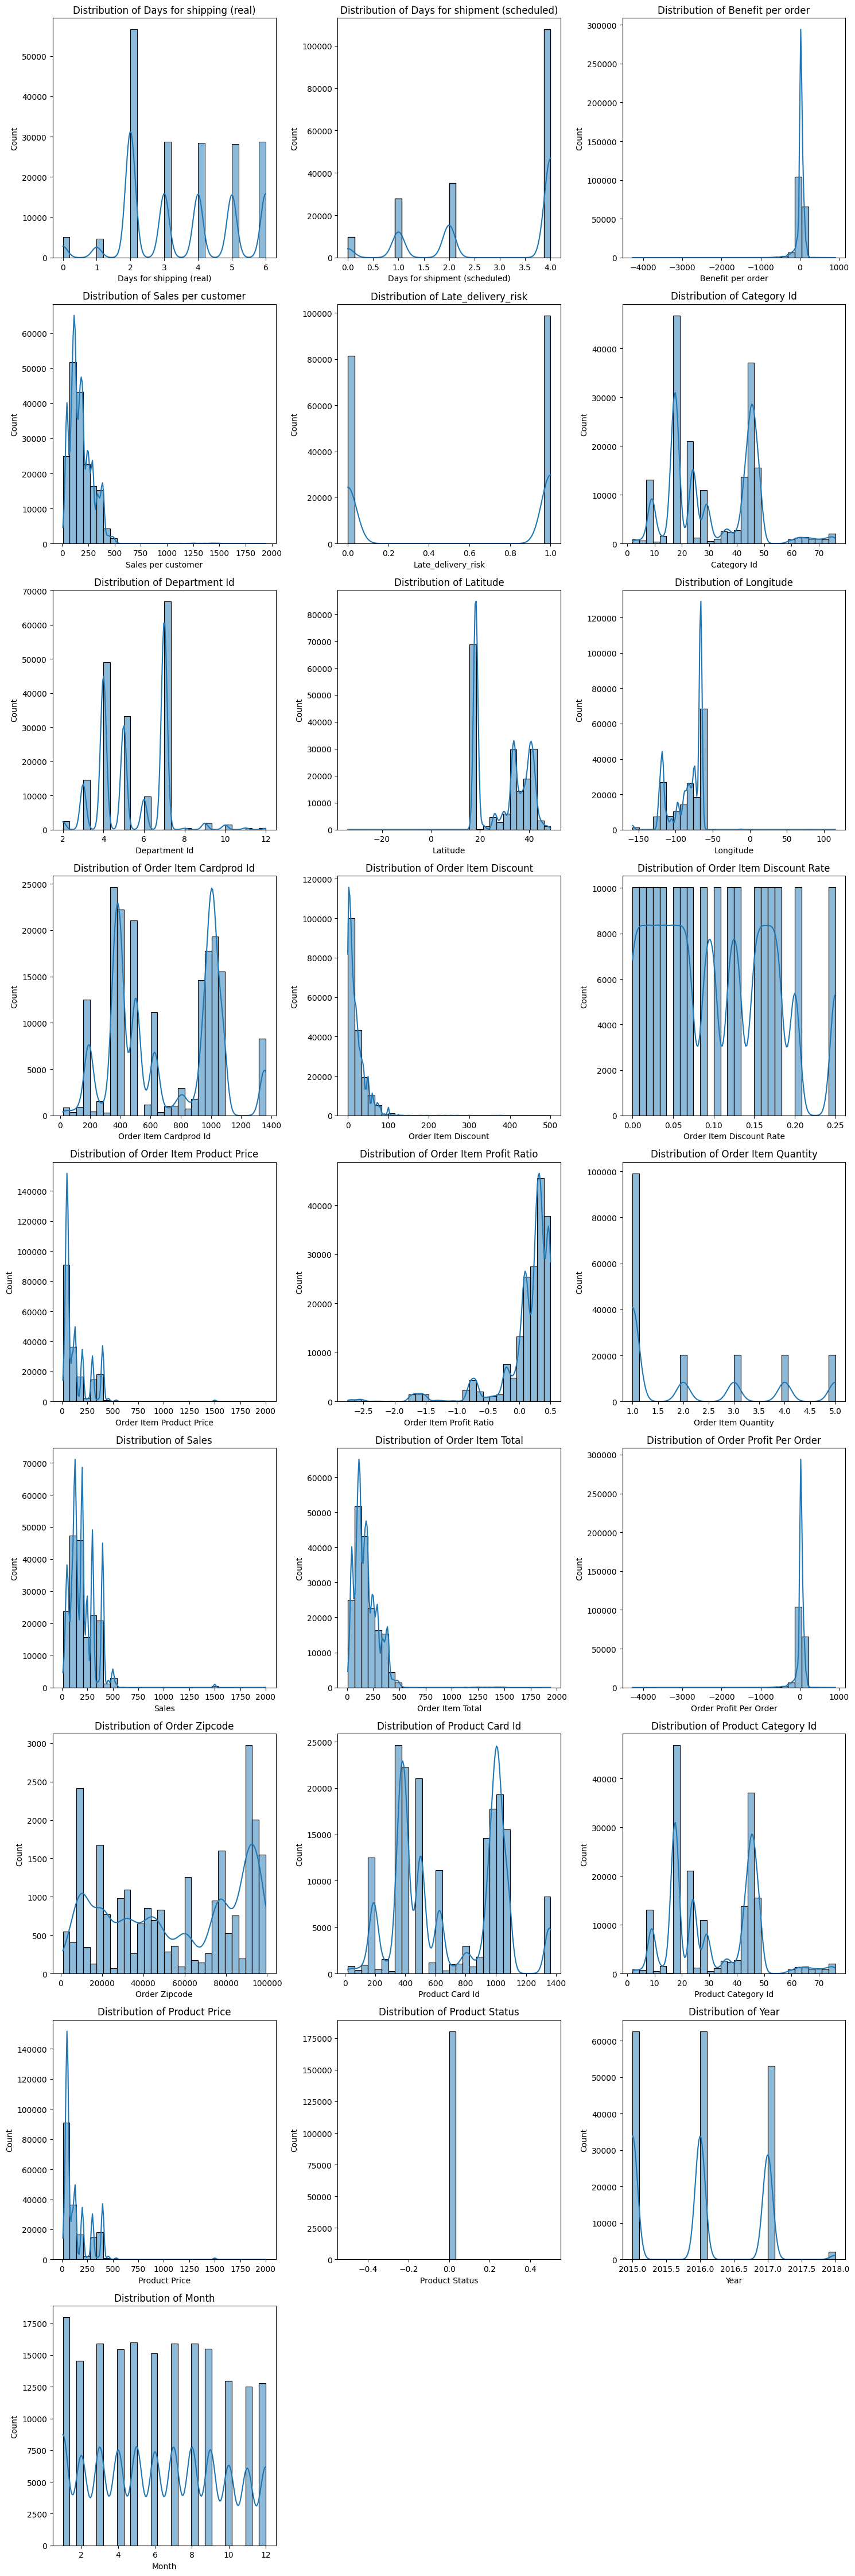

In [19]:
numerical_data = df.select_dtypes(include=[np.number]).drop(columns=['Order Id', 'Order Customer Id',
                                                                    'Customer Id', 'Order Item Id'])

num_cols = numerical_data.shape[1]
n_rows = (num_cols // 3) + (num_cols % 3 > 0)

plt.figure(figsize=(15, 5 * n_rows))
for idx, col in enumerate(numerical_data.columns):
    plt.subplot(n_rows, 3, idx + 1)
    sns.histplot(numerical_data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Unique Years Across the Dataset

In [20]:
# All unique year values
df['Year'] = df['order date (DateOrders)'].dt.year
unique_years = df['Year'].unique()

df['ShippingYear'] = df['shipping date (DateOrders)'].dt.year
unique_shipping_years = df['ShippingYear'].unique()

print(f'The unique years in the order data are: {unique_years}')
print(f'The unique years in the shipping data are: {unique_shipping_years}')

# Find the earliest year
earliest_order_date = df['order date (DateOrders)'].dt.date.min()
latest_order_date = df['order date (DateOrders)'].dt.date.max()

earliest_ship_date = df['shipping date (DateOrders)'].dt.date.min()
latest_ship_date = df['shipping date (DateOrders)'].dt.date.max()

print(f'The earliest order date in the data is: {earliest_order_date}')
print(f'The latest order date in the data is: {latest_order_date}')
print(f'The earliest shipping date in the data is: {earliest_ship_date}')
print(f'The latest shipping date in the data is: {latest_ship_date}')

The unique years in the order data are: [2018 2016 2015 2017]
The unique years in the shipping data are: [2018 2016 2017 2015]
The earliest order date in the data is: 2015-01-01
The latest order date in the data is: 2018-01-31
The earliest shipping date in the data is: 2015-01-03
The latest shipping date in the data is: 2018-02-06


# Order Count Over Time by Status

In [21]:
order_subset = df.iloc[:, 25:41]
order_subset['order_YearMonth'] = order_subset['order date (DateOrders)'].dt.strftime('%Y-%m')
order_subset

,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,order_YearMonth
0,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.750000,0.29,1,327.750000,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,2018-01
1,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.750000,-0.80,1,327.750000,311.359985,-249.089996,South Asia,Rajastán,PENDING,2018-01
2,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.750000,-0.80,1,327.750000,309.720001,-247.779999,South Asia,Rajastán,CLOSED,2018-01
3,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.750000,0.08,1,327.750000,304.809998,22.860001,Oceania,Queensland,COMPLETE,2018-01
4,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.750000,0.45,1,327.750000,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,2018-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,1005,2016-01-16 03:40:00,26043,1004,0.000000,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,2016-01
180515,9141,2016-01-16 01:34:00,26037,1004,4.000000,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,2016-01
180516,291,2016-01-15 21:00:00,26024,1004,8.000000,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,2016-01
180517,2813,2016-01-15 20:18:00,26022,1004,12.000000,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,2016-01


In [22]:
order_grouped = order_subset.groupby(["order_YearMonth", "Order Status"])["Order Item Id"].count().reset_index()
order_grouped = order_grouped.rename(columns = {"Order Item Id": "Order Counts"})
order_grouped

,order_YearMonth,Order Status,Order Counts
0,2015-01,CANCELED,84
1,2015-01,CLOSED,560
2,2015-01,COMPLETE,1760
3,2015-01,ON_HOLD,270
4,2015-01,PAYMENT_REVIEW,50
...,...,...,...
328,2018-01,PAYMENT_REVIEW,28
329,2018-01,PENDING,227
330,2018-01,PENDING_PAYMENT,451
331,2018-01,PROCESSING,252


In [27]:
import nbformat
print(nbformat.__version__)

5.10.4


In [30]:
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

In [31]:
fig = px.line(order_grouped, x = "order_YearMonth", y = "Order Counts", color = "Order Status",
              title = "Order Count Over Time by Status",
              labels = {"order_count": "Order Count", "order_YearMonth": "Order Date", "order_status": "Order Status"},
              markers = True)

fig.show()

## Order Count Over Time

In [33]:
order_grouped2 = order_subset.groupby(["order_YearMonth"])["Order Item Id"].count().reset_index()
order_grouped2 = order_grouped2.rename(columns = {"Order Item Id": "Order Counts"})
order_grouped2.head()

,order_YearMonth,Order Counts
0,2015-01,5322
1,2015-02,4729
2,2015-03,5362
3,2015-04,5126
4,2015-05,5357


In [34]:
fig = px.line(order_grouped2, x = "order_YearMonth", y = "Order Counts", title='Order Count Over Time', 
              markers=True)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Order Count',
    xaxis=dict(
        tickmode='auto',
        nticks=20,
        tickformat='%b %d, %Y'
    ),
    yaxis=dict(
        tickmode='auto',
        nticks=10
    )
)

fig.show()

# Correlation Analysis

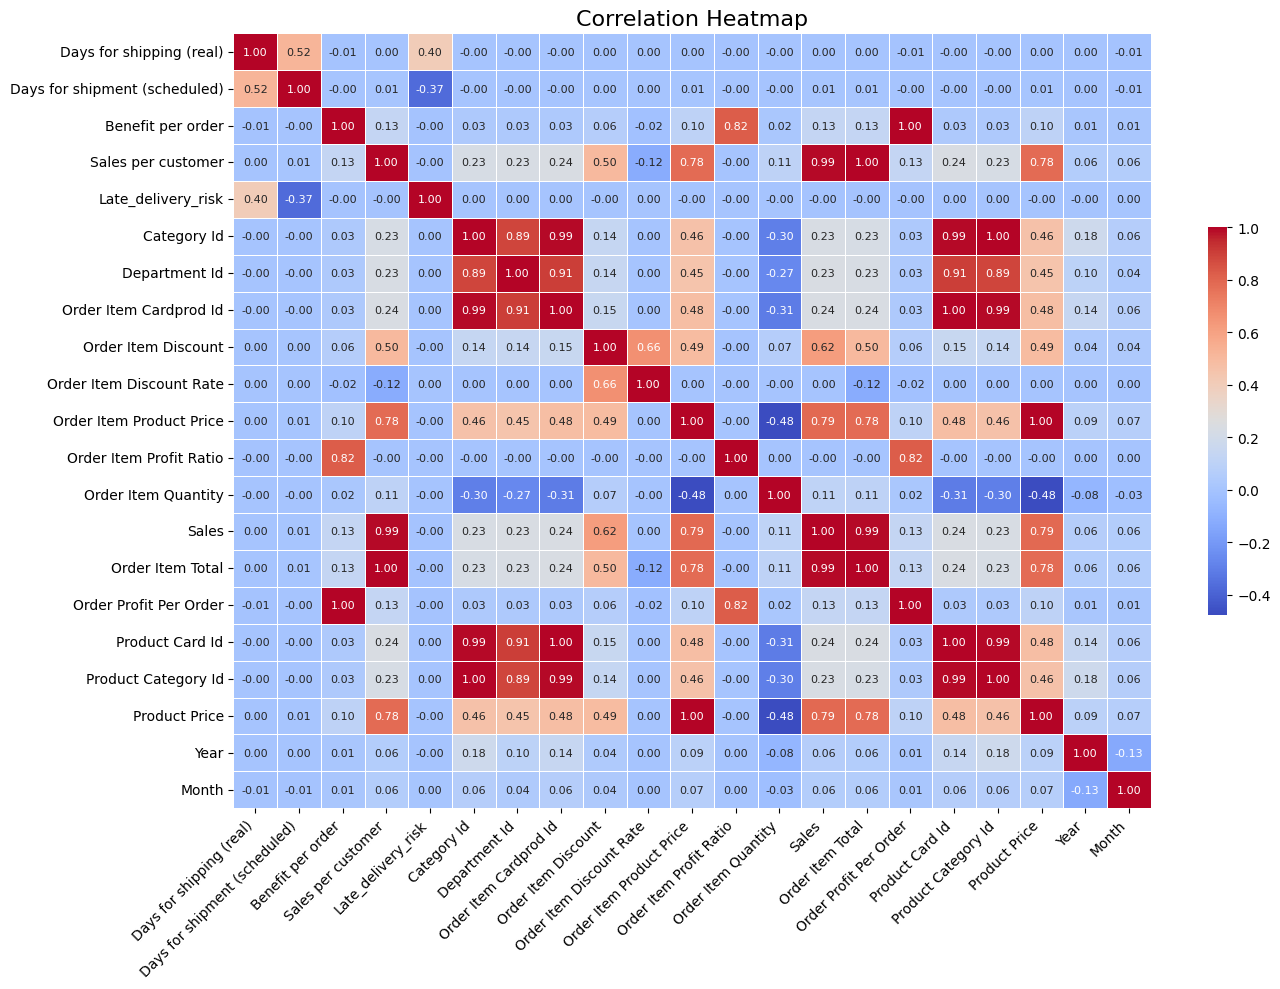

In [35]:
correlation_matrix = numerical_data.drop(columns=['Order Zipcode', 'Latitude', 'Longitude', 'Product Status']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            annot_kws={"size": 8}, 
            linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap', size=16)
plt.xticks(rotation=45, ha="right")  
plt.yticks(rotation=0)
plt.tight_layout()

# Categorical Features Analysis

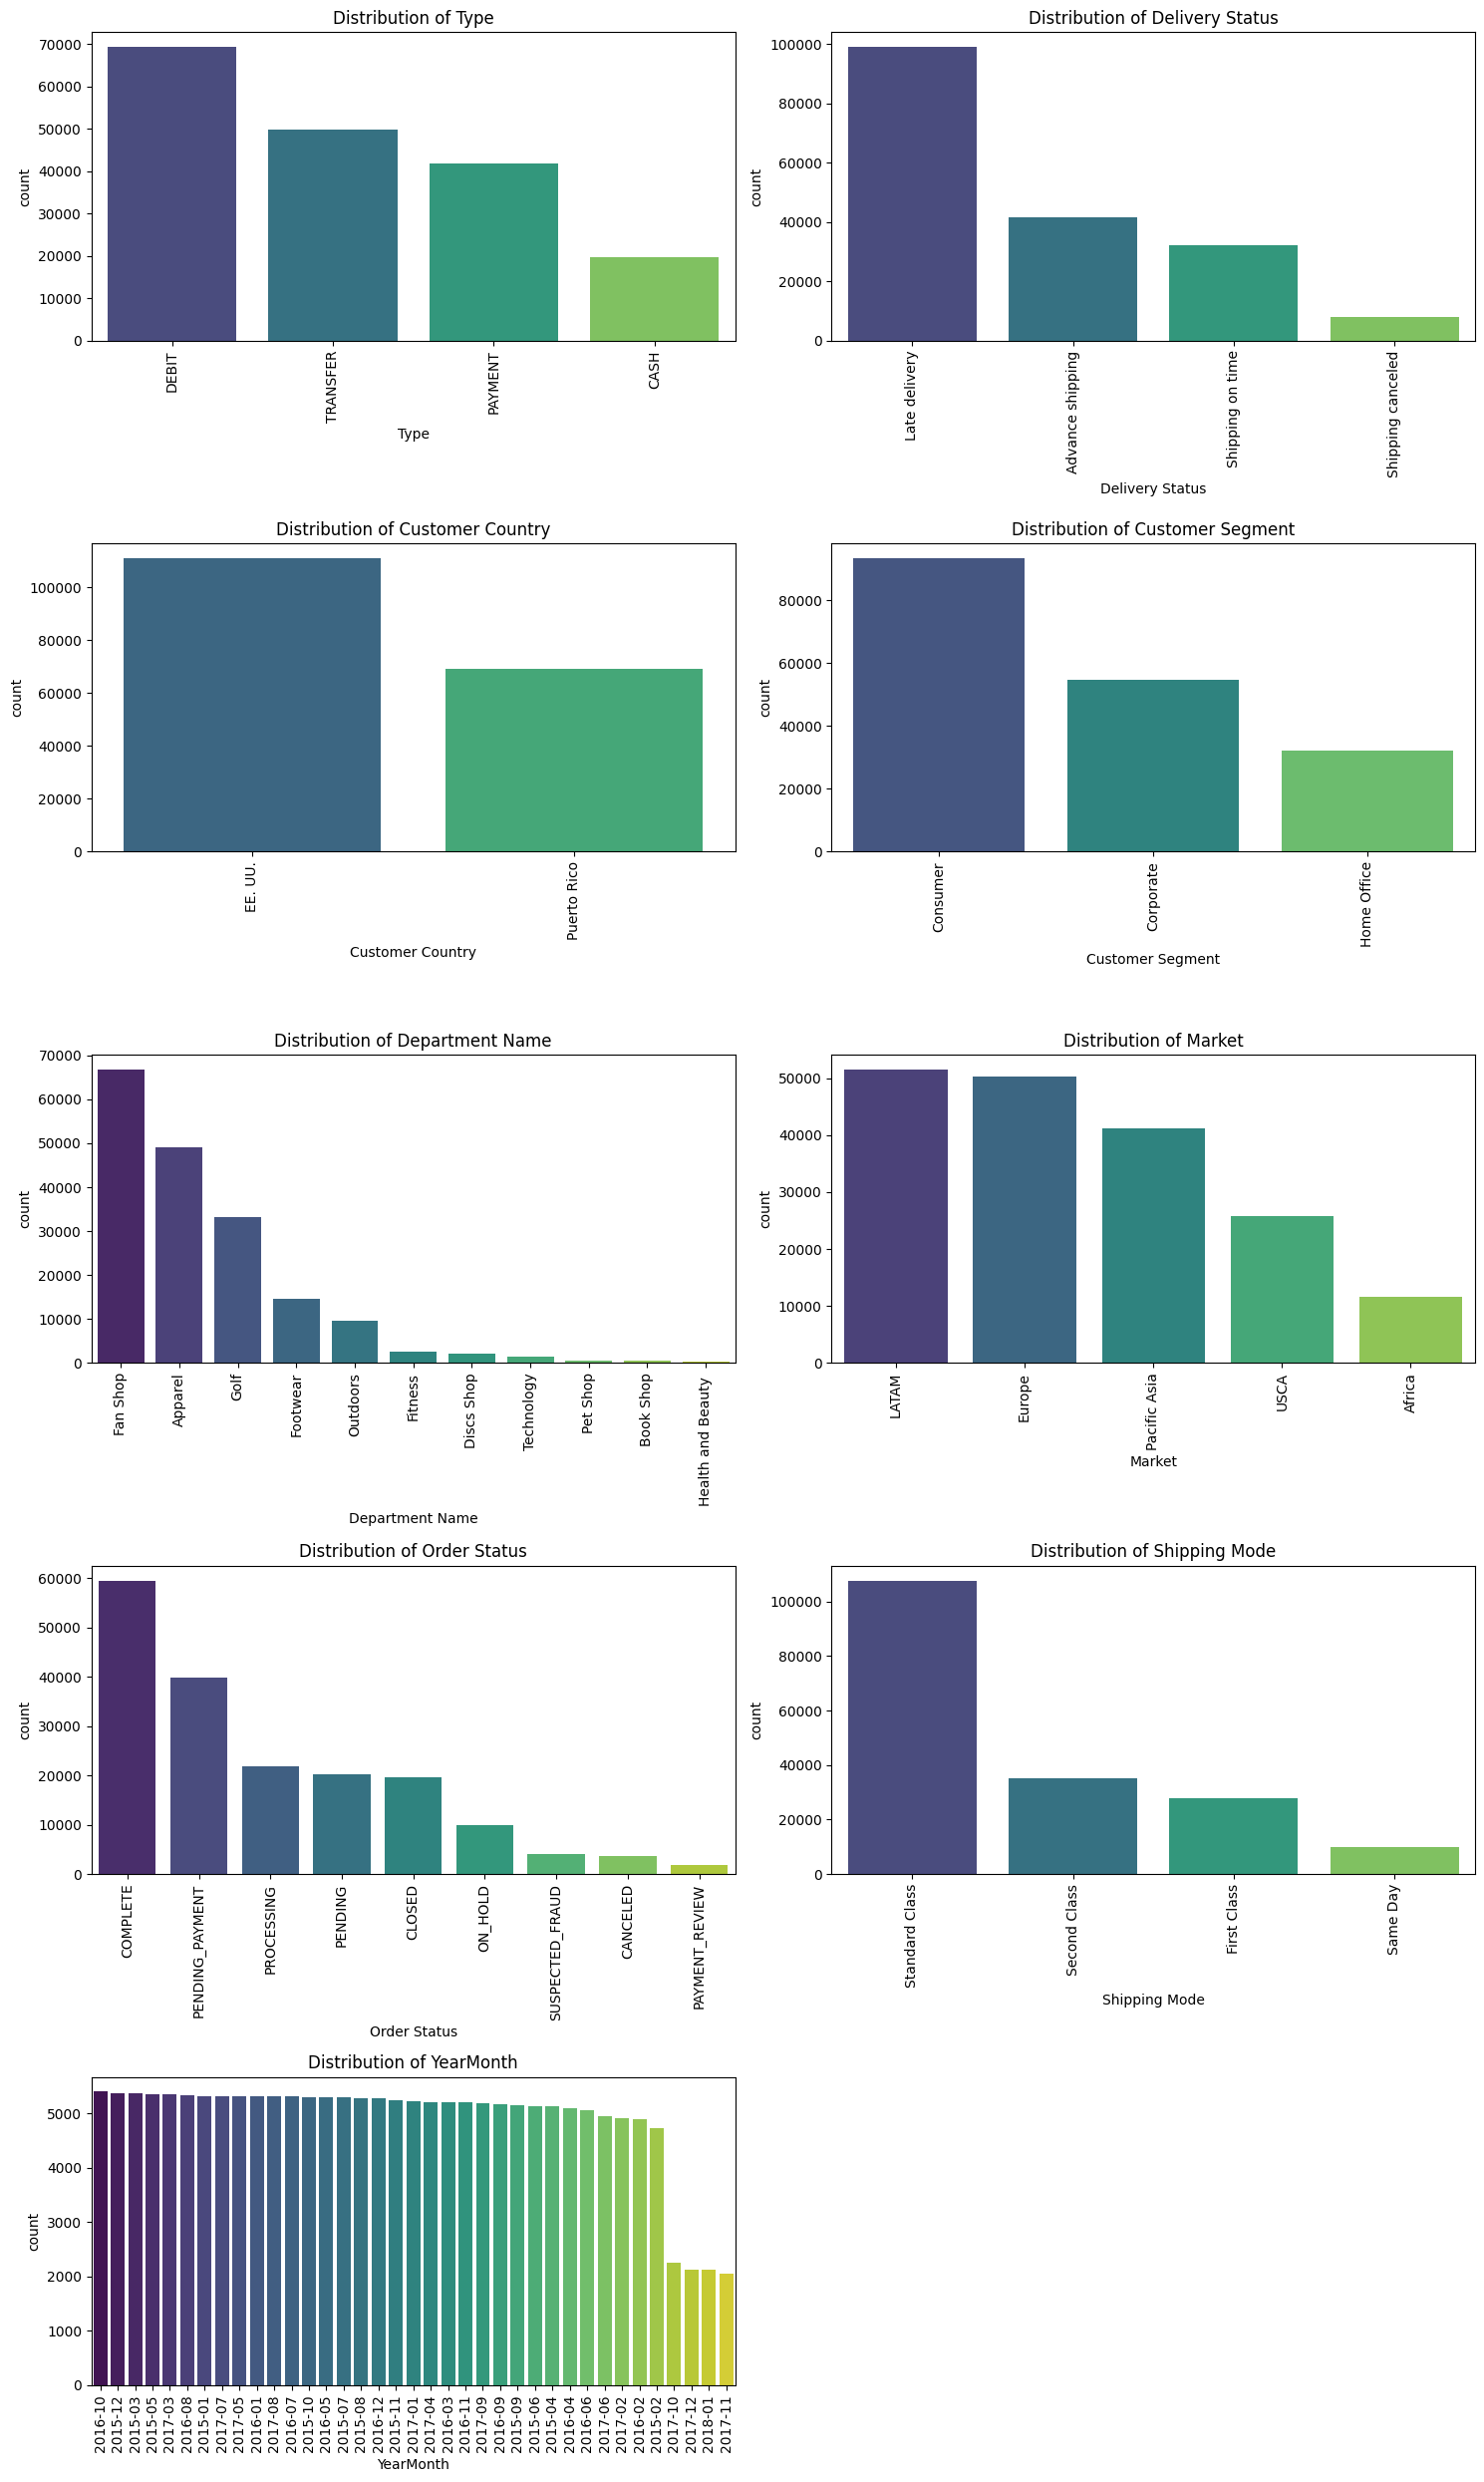

In [36]:
categorical_data = df.select_dtypes(include=['object']).drop(columns=['Customer City', 
                    'Customer Fname', 'Customer Lname', 'Customer Zipcode', 'Customer Street',
                    'Order City', 'Order State', 'Product Name', 'Category Name', 'Customer State', 
                    'Order Country', 'Order Region'])

num_cols = categorical_data.shape[1]
n_rows = (num_cols // 2) + (num_cols % 2 > 0)

plt.figure(figsize=(15, 5 * n_rows))
for idx, col in enumerate(categorical_data.columns):
    plt.subplot(n_rows, 2, idx + 1)
    sns.countplot(x=categorical_data[col], palette="viridis", order=categorical_data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=90) 
    plt.tight_layout()

plt.show()

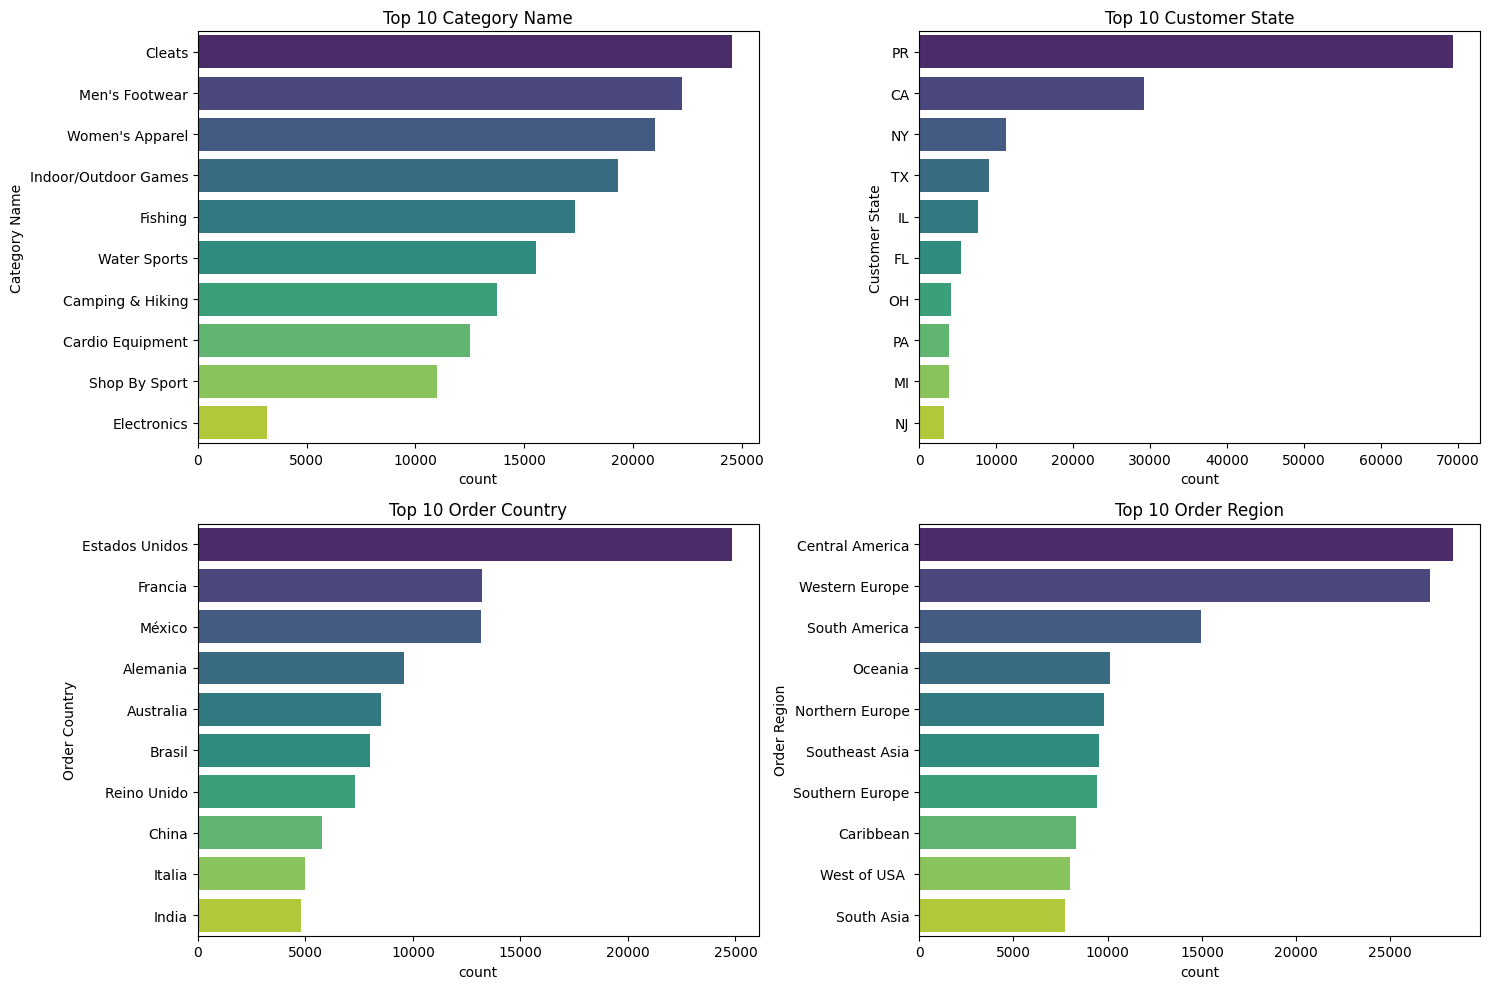

In [37]:
# Select the categorical columns that have more than 10 distinct values
categorical_data2 = df[['Category Name', 'Customer State', 'Order Country', 'Order Region']]

num_cols = categorical_data2.shape[1]
n_rows = (num_cols // 2) + (num_cols % 2 > 0)

plt.figure(figsize=(15, 5 * n_rows))
for idx, col in enumerate(categorical_data2.columns):
    plt.subplot(n_rows, 2, idx + 1)
    category_counts = categorical_data2[col].value_counts().head(10)
    sns.barplot(x=category_counts, y=category_counts.index, palette="viridis")
    plt.title(f'Top 10 {col}')
    plt.tight_layout()

plt.show()

# Sales Trend Analysis

## Monthly & Annually Sales Trend

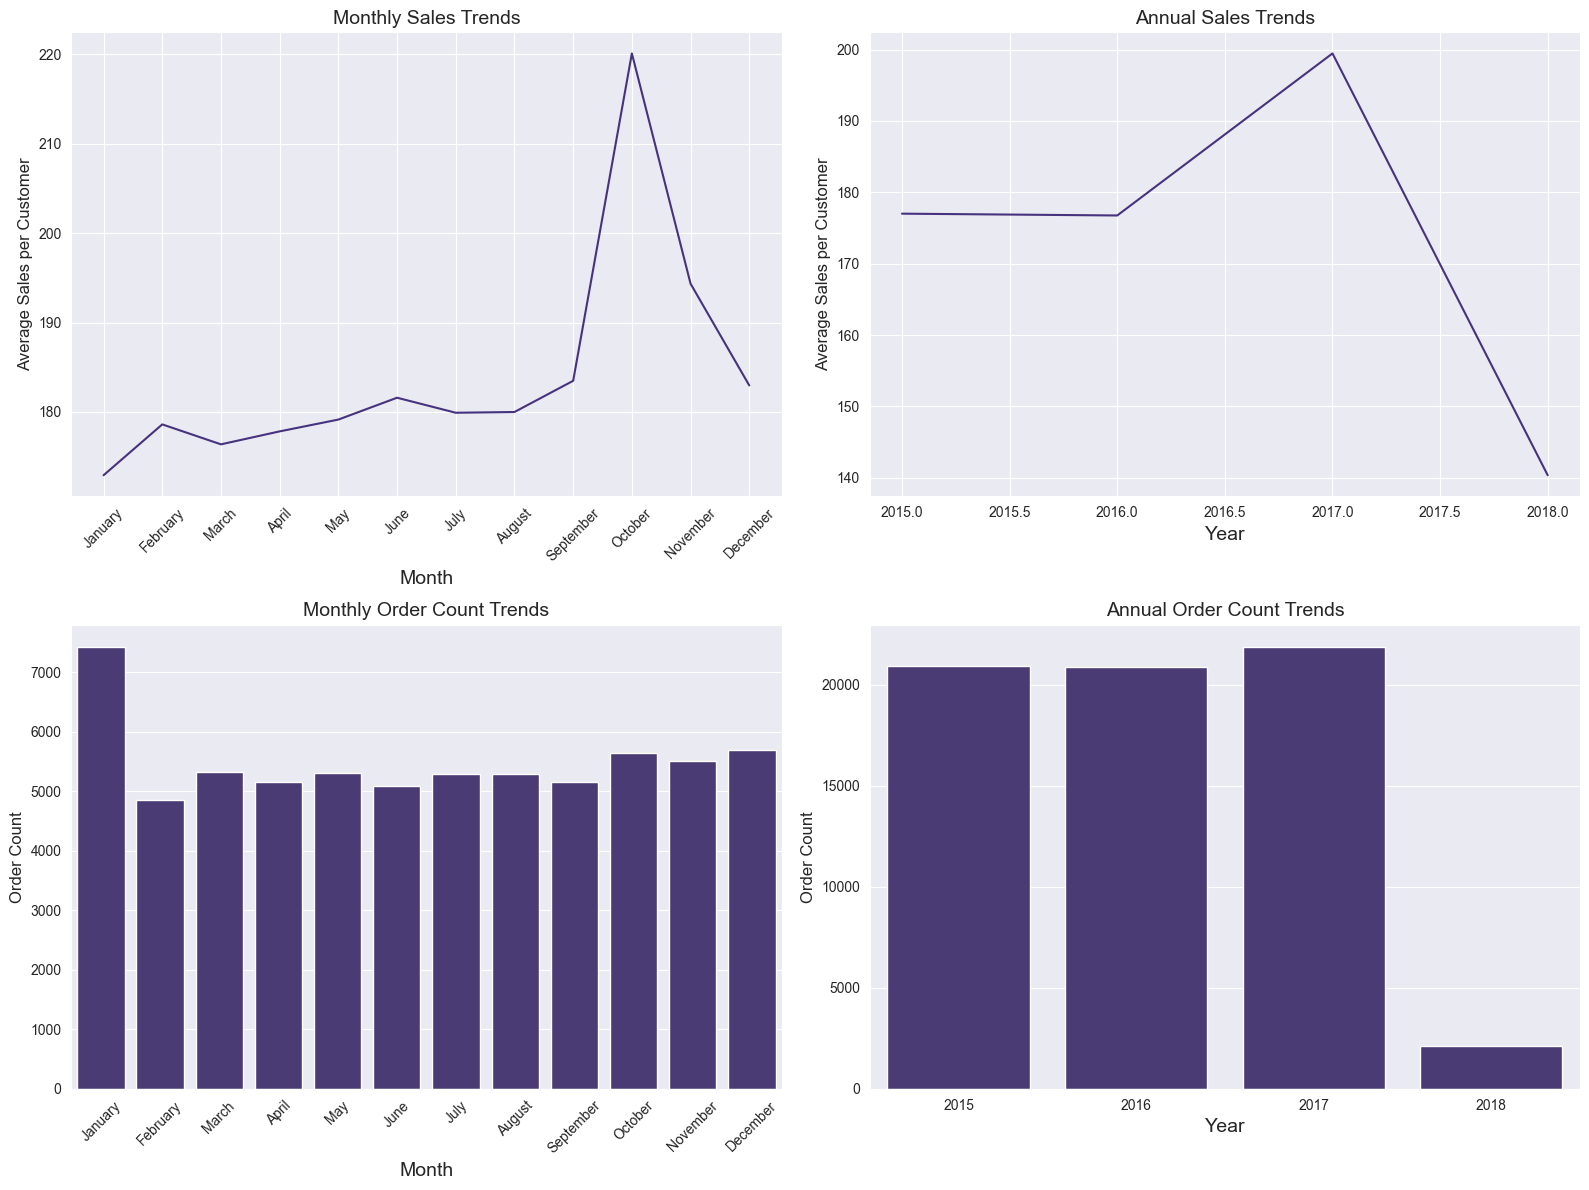

In [38]:
months_in_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
df['MonthName'] = df['order date (DateOrders)'].dt.month_name()
df['MonthName'] = pd.Categorical(df['MonthName'], categories=months_in_order, ordered=True)

monthly_sales = df.groupby('MonthName')['Sales per customer'].mean()
yearly_sales = df.groupby('Year')['Sales per customer'].mean()

monthly_order_count = df.groupby('MonthName')['Order Id'].nunique()
yearly_order_count = df.groupby('Year')['Order Id'].nunique()

sns.set_palette("viridis")
sns.set_style("darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Monthly sales trends
sns.lineplot(data=monthly_sales, ax=axs[0, 0])
axs[0, 0].set_title('Monthly Sales Trends', fontsize=14)
axs[0, 0].set_xlabel('Month', fontsize=14)
axs[0, 0].set_ylabel('Average Sales per Customer', fontsize=12)
axs[0, 0].set_xticklabels(months_in_order, rotation=45)

# Annual sales trends
sns.lineplot(data=yearly_sales, ax=axs[0, 1])
axs[0, 1].set_title('Annual Sales Trends', fontsize=14)
axs[0, 1].set_xlabel('Year', fontsize=14)
axs[0, 1].set_ylabel('Average Sales per Customer', fontsize=12)

# Monthly order count trends
sns.barplot(x=monthly_order_count.index, y=monthly_order_count.values, ax=axs[1, 0])
axs[1, 0].set_title('Monthly Order Count Trends', fontsize=14)
axs[1, 0].set_xlabel('Month', fontsize=14)
axs[1, 0].set_ylabel('Order Count', fontsize=12)
axs[1, 0].set_xticklabels(months_in_order, rotation=45)

# Annual order count trends
sns.barplot(x=yearly_order_count.index, y=yearly_order_count.values, ax=axs[1, 1])
axs[1, 1].set_title('Annual Order Count Trends', fontsize=14)
axs[1, 1].set_xlabel('Year', fontsize=14)
axs[1, 1].set_ylabel('Order Count', fontsize=12)

plt.tight_layout()
plt.show()

## Monthly Sales & Profit Ratio & Discount Rate Average Trend

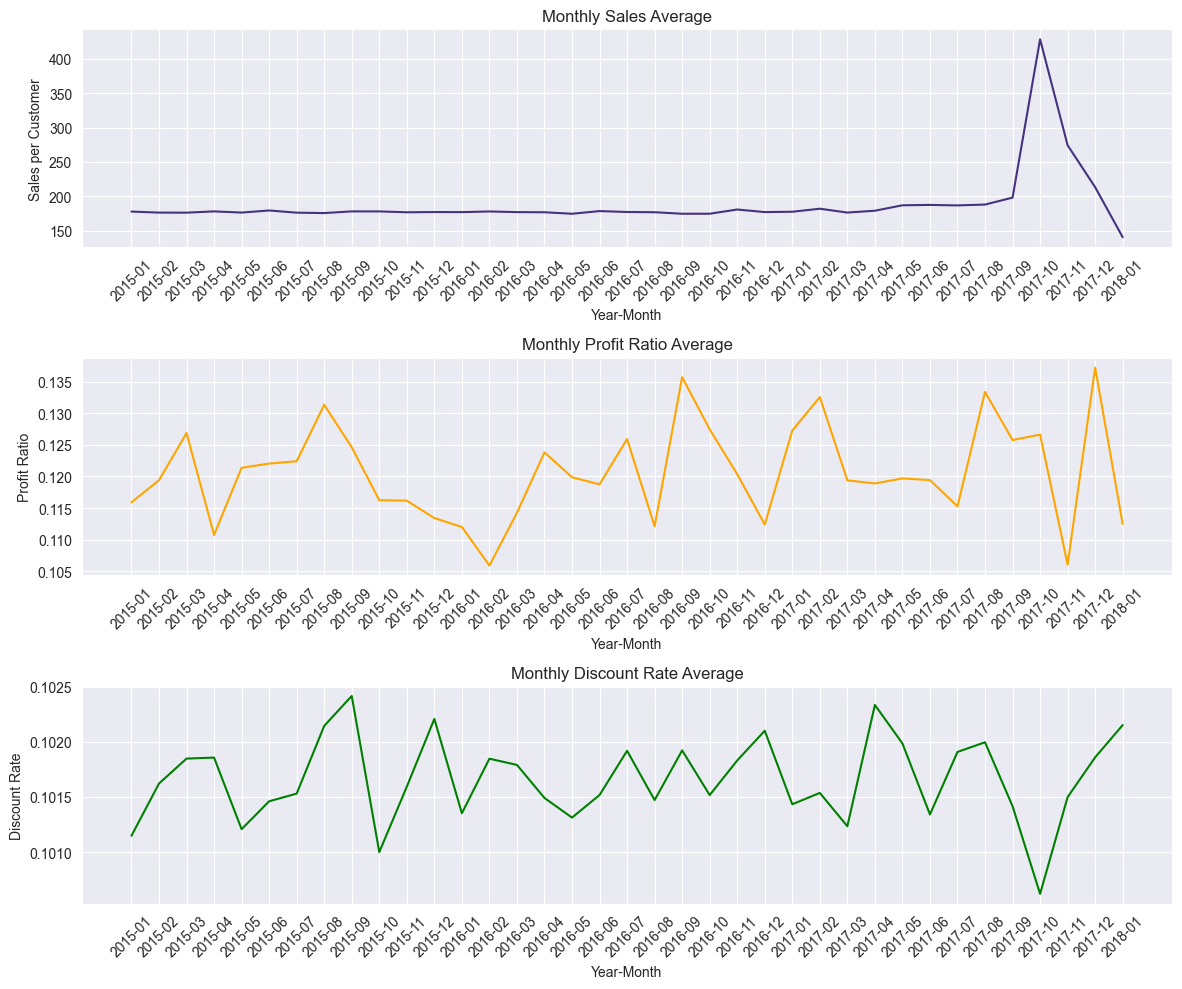

In [39]:
monthly_sales_avg = df.groupby('YearMonth')['Sales per customer'].mean()
monthly_profit_ratio_avg = df.groupby('YearMonth')['Order Item Profit Ratio'].mean()
monthly_discount_rate_avg = df.groupby('YearMonth')['Order Item Discount Rate'].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 10)) 

# Plot Monthly Sales Average
sns.lineplot(ax=axes[0], x=monthly_sales_avg.index, y=monthly_sales_avg)
axes[0].set_title('Monthly Sales Average')
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Sales per Customer')
axes[0].tick_params(axis='x', rotation=45)

# Plot Monthly Profit Ratio Average
sns.lineplot(ax=axes[1], x=monthly_profit_ratio_avg.index, y=monthly_profit_ratio_avg, color='orange')
axes[1].set_title('Monthly Profit Ratio Average')
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Profit Ratio')
axes[1].tick_params(axis='x', rotation=45)

# Plot Monthly Order Item Discount Rate Average
sns.lineplot(ax=axes[2], x=monthly_discount_rate_avg.index, y=monthly_discount_rate_avg, color='green')
axes[2].set_title('Monthly Discount Rate Average')
axes[2].set_xlabel('Year-Month')
axes[2].set_ylabel('Discount Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# OLS Regression Report (for Total Profit Per Order)

In [40]:
df['Total Profit Per Order'] = df['Order Profit Per Order']*df['Order Item Quantity']
X = df[['Order Item Discount Rate', 'Product Price', 'Order Item Quantity']]
y = df['Total Profit Per Order']  
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Total Profit Per Order   R-squared:                       0.026
Model:                                OLS   Adj. R-squared:                  0.026
Method:                     Least Squares   F-statistic:                     1597.
Date:                    Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                            12:24:58   Log-Likelihood:            -1.2704e+06
No. Observations:                  180519   AIC:                         2.541e+06
Df Residuals:                      180515   BIC:                         2.541e+06
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

# Multiple Numerical Features Analysis

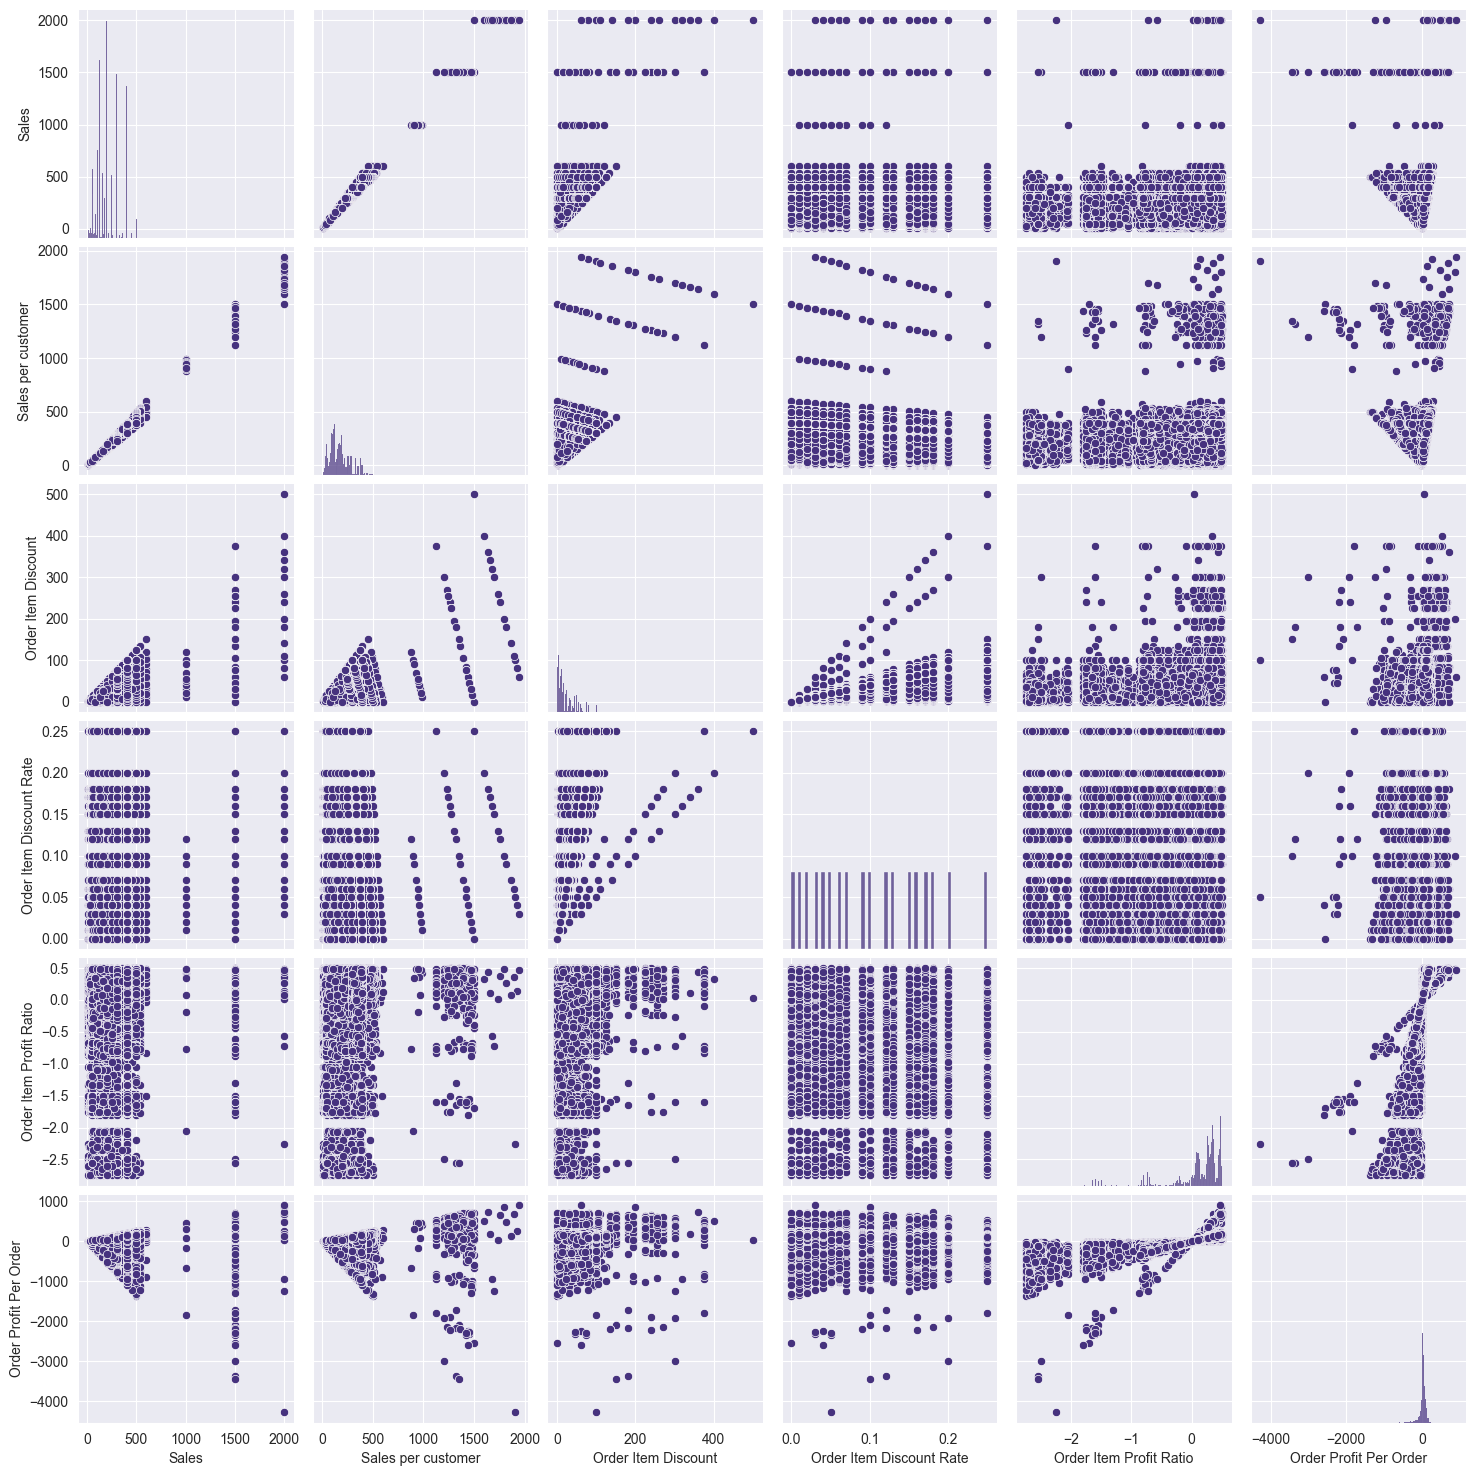

In [41]:
numerical_cols = ['Sales', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 
                   'Order Item Profit Ratio', 'Order Profit Per Order' ]
df_selected = df[numerical_cols]
sns.pairplot(df_selected)
plt.show()

# Fraud Order Analysis

## Order Status Distribution

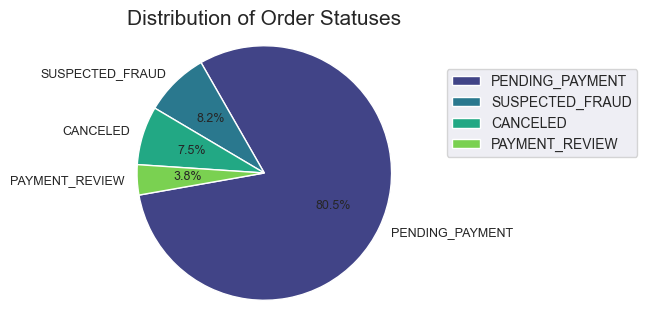

In [42]:
sns.set_palette("viridis")
sns.set_style("darkgrid")

relevant_statuses = ['SUSPECTED_FRAUD', 'CANCELED', 'COMPLETED', 'PENDING_PAYMENT', 'PAYMENT_REVIEW']
df_filtered = df[df['Order Status'].isin(relevant_statuses)]

status_counts = df_filtered['Order Status'].value_counts()
colors = sns.color_palette("viridis", len(status_counts))

plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(status_counts, labels=status_counts.index, colors=colors, autopct='%1.1f%%', startangle=190)

for text in texts + autotexts:
    text.set_fontsize(9)

plt.title('Distribution of Order Statuses', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular
plt.legend(fontsize=10, bbox_to_anchor=(0.7,0.4), loc="center right", bbox_transform=plt.gcf().transFigure) 
plt.subplots_adjust(top=0.5, left=0.0, bottom=0.15, right=0.45)
plt.show()

## Fraud v.s. Non-Fraud on Categorical Features

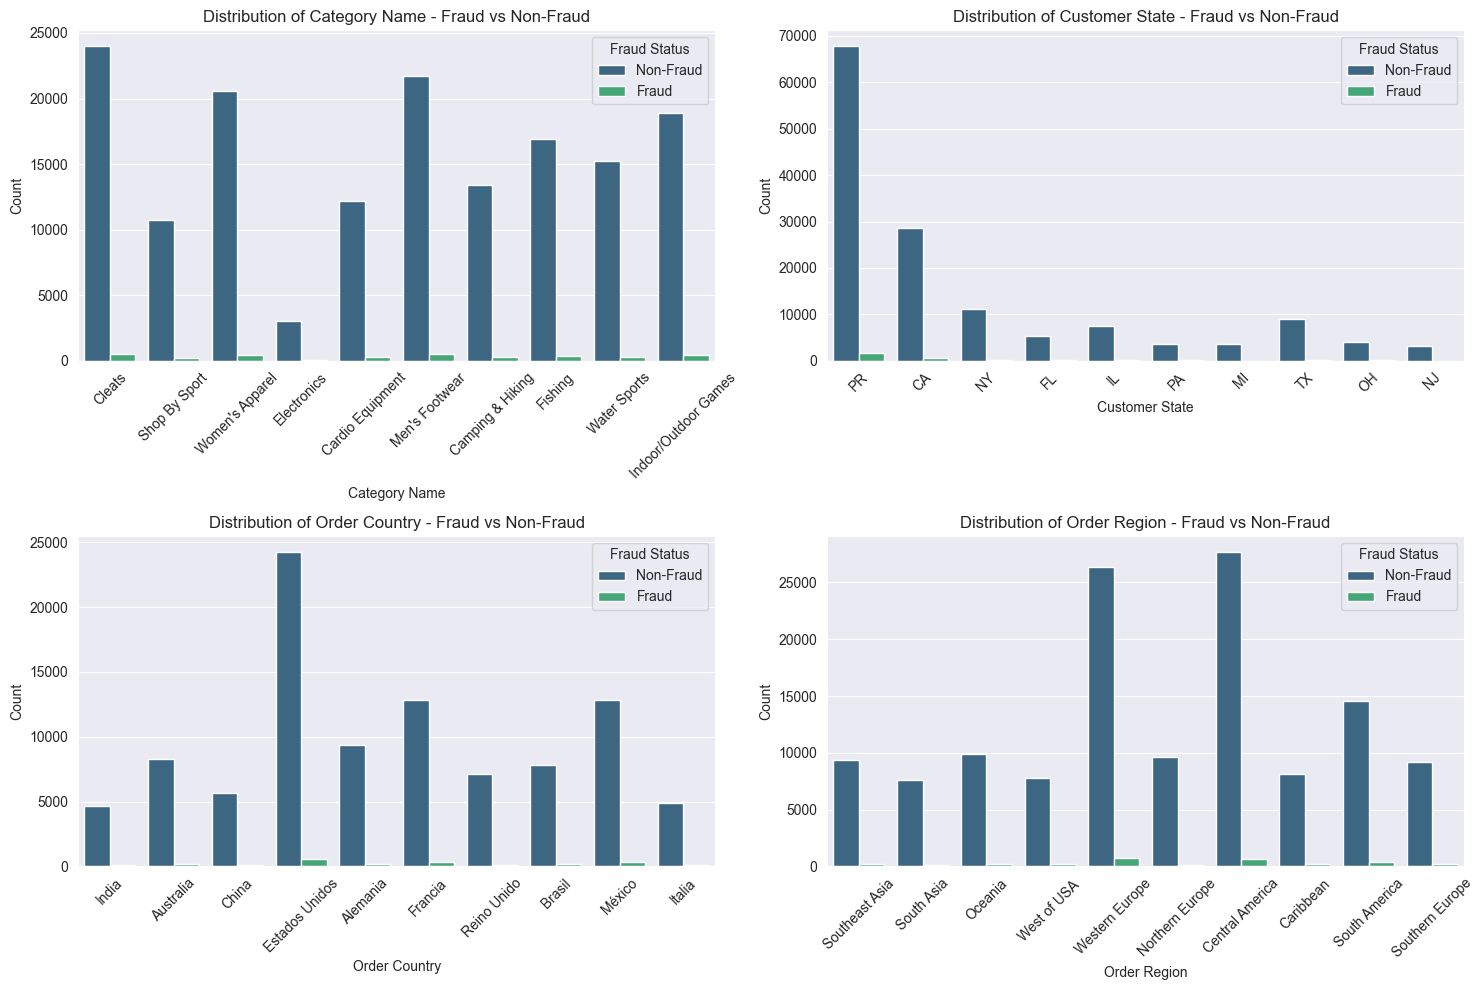

In [43]:
selected_categorical_columns = ['Category Name', 'Customer State', 'Order Country', 'Order Region']

df['Fraud Status'] = df['Order Status'].apply(lambda x: 'Fraud' if x == 'SUSPECTED_FRAUD' else 'Non-Fraud')

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for idx, col in enumerate(selected_categorical_columns):
    # Filter to top 10 categories for readability
    top_categories = df[col].value_counts().head(10).index
    filtered_data = df[df[col].isin(top_categories)]
    
    sns.countplot(data=filtered_data, x=col, hue='Fraud Status', ax=axs[idx], palette="viridis")
    axs[idx].set_title(f'Distribution of {col} - Fraud vs Non-Fraud')
    axs[idx].set_xlabel(col)
    axs[idx].set_ylabel('Count')
    axs[idx].legend(title='Fraud Status')
    axs[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Fraud v.s. Non-Fraud on Numerical Features

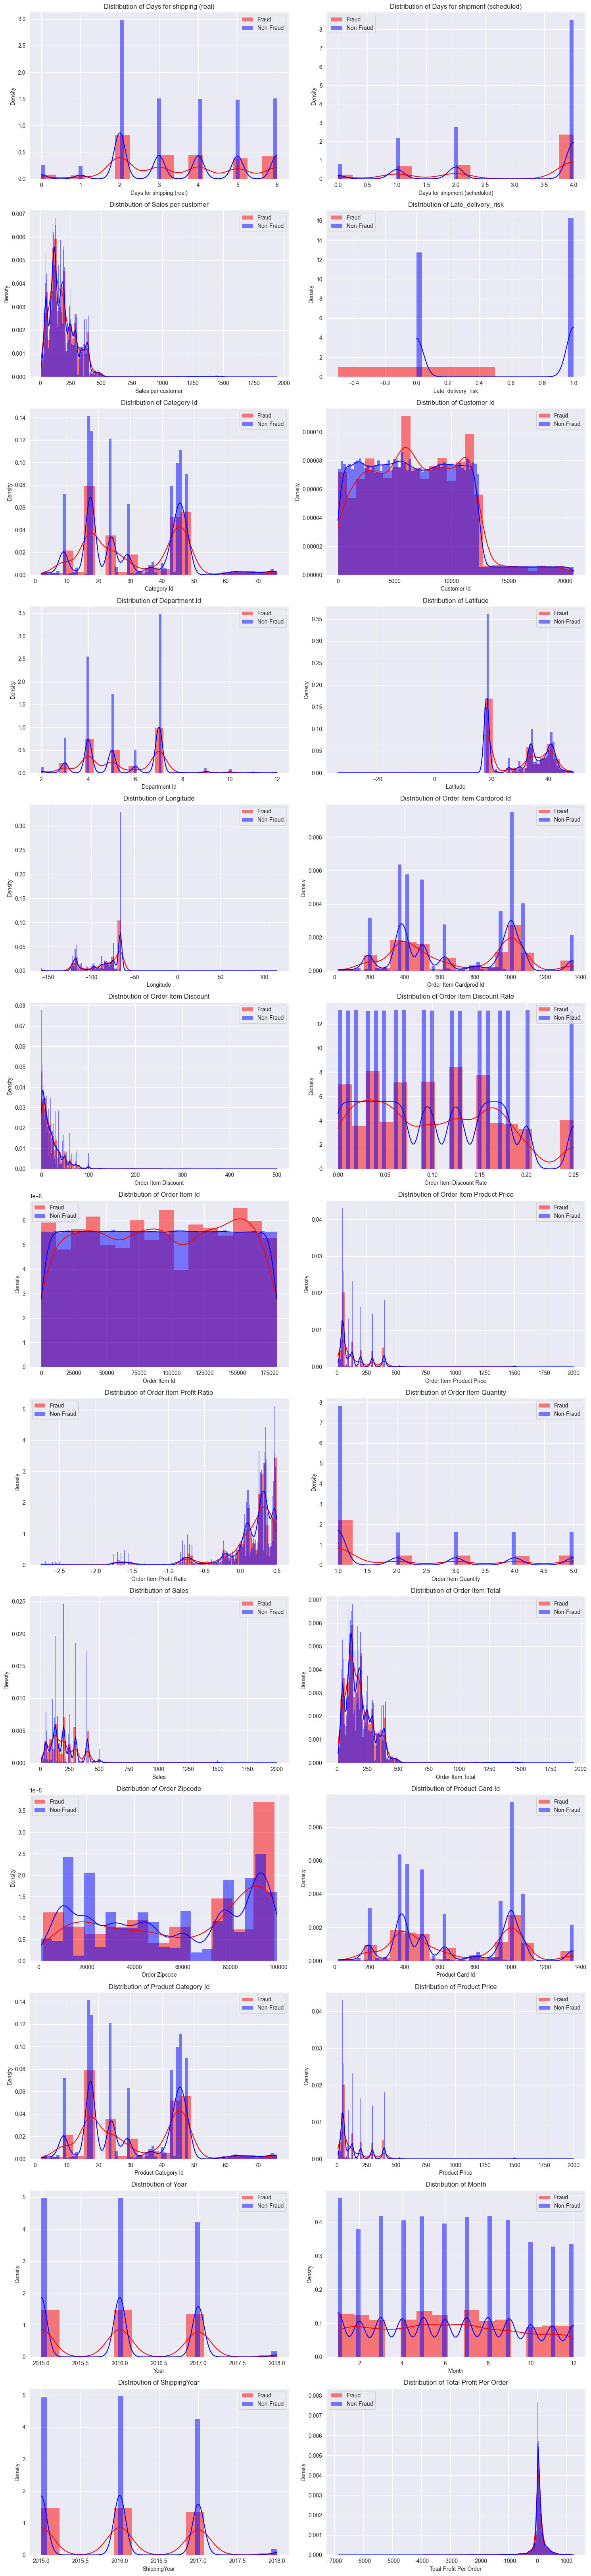

In [44]:
fraud_df = df[df['Order Status'] == 'SUSPECTED_FRAUD']
non_fraud_df = df[df['Order Status'] != 'SUSPECTED_FRAUD']

numerical_columns = fraud_df.select_dtypes(include=[np.number])\
                    .drop(columns=['Product Status', 'Order Profit Per Order', 'Benefit per order'
                                  , 'Order Id', 'Order Customer Id']).columns

n_rows = (len(numerical_columns) // 2) + (len(numerical_columns) % 2 > 0)

plt.figure(figsize=(15, 5 * n_rows))

for idx, col in enumerate(numerical_columns):
    plt.subplot(n_rows, 2, idx + 1)
    sns.histplot(fraud_df[col], color='red', label='Fraud', kde=True, stat="density", linewidth=0)
    sns.histplot(non_fraud_df[col], color='blue', label='Non-Fraud', kde=True, stat="density", linewidth=0)
    plt.legend()
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

## Fraud Trend per Month & per Year

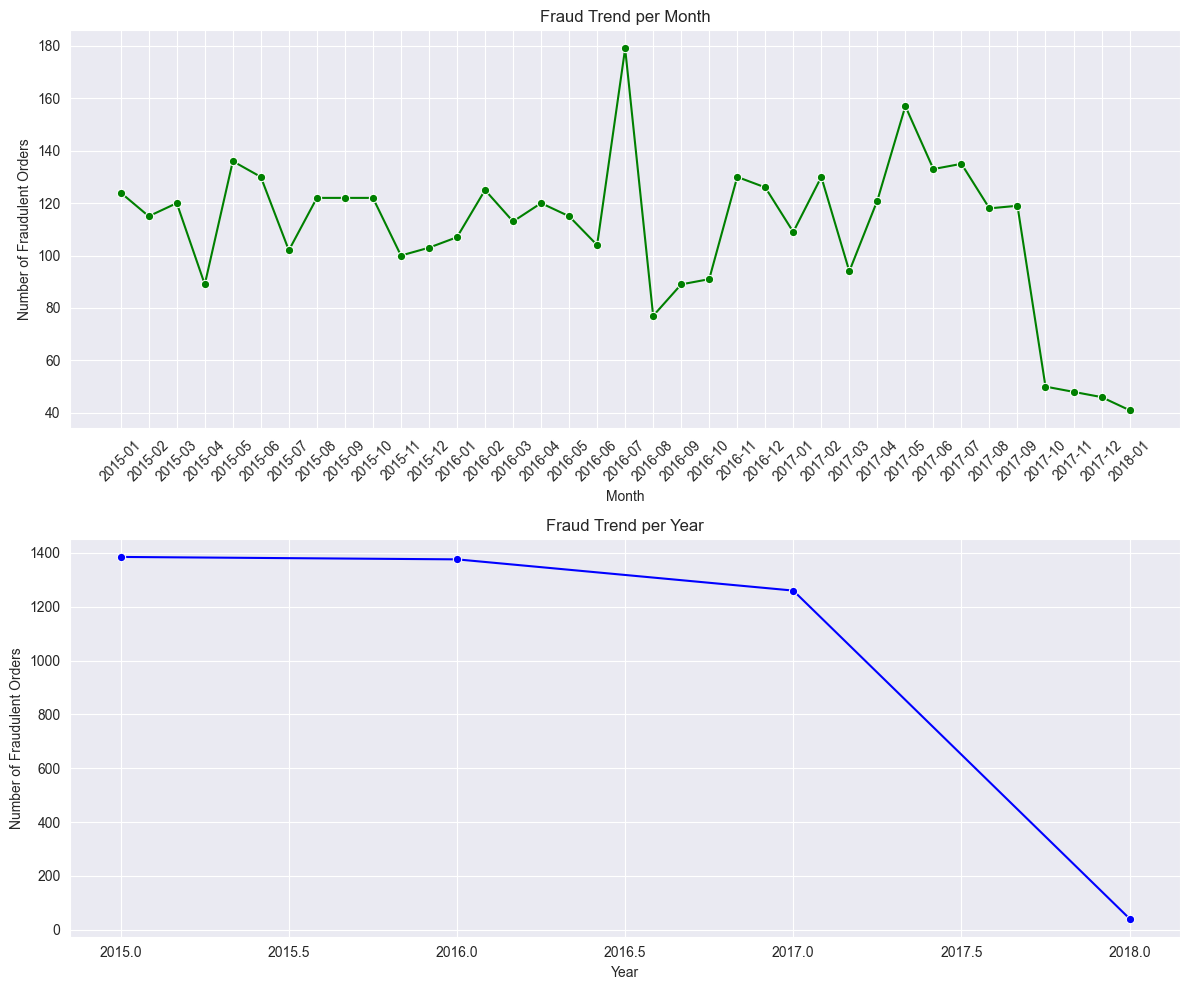

In [45]:
fraud_df = df[df['Order Status'] == 'SUSPECTED_FRAUD']

monthly_fraud_trend = fraud_df.groupby('YearMonth').size()
yearly_fraud_trend = fraud_df.groupby('Year').size()

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot the monthly fraud trend
sns.lineplot(x=monthly_fraud_trend.index, y=monthly_fraud_trend.values, ax=axs[0], marker='o', color='green')
axs[0].set_title('Fraud Trend per Month')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Number of Fraudulent Orders')
axs[0].tick_params(axis='x', rotation=45)

# Plot the yearly fraud trend
sns.lineplot(x=yearly_fraud_trend.index, y=yearly_fraud_trend.values, ax=axs[1], marker='o', color='blue')
axs[1].set_title('Fraud Trend per Year')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Number of Fraudulent Orders')

plt.tight_layout()
plt.show()

## Top 10 Customers by Fraud & Cancellation Count

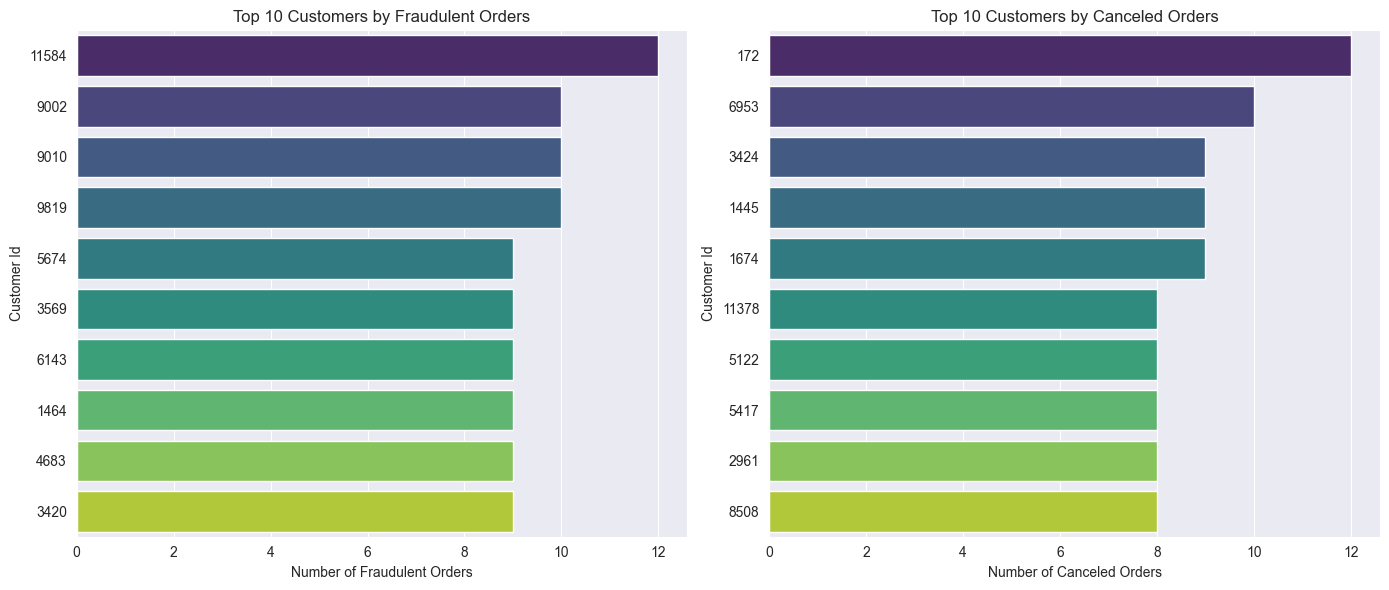

In [46]:
fraud_orders = df[df['Order Status'] == 'SUSPECTED_FRAUD']
canceled_orders = df[df['Order Status'] == 'CANCELED']

top_fraud_customers = fraud_orders['Customer Id'].value_counts().nlargest(10)
top_canceled_customers = canceled_orders['Customer Id'].value_counts().nlargest(10)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot for top 10 customers with fraudulent orders
sns.barplot(y=top_fraud_customers.index.astype(str), x=top_fraud_customers.values, ax=axs[0], palette="viridis", ci=None)
axs[0].set_title('Top 10 Customers by Fraudulent Orders')
axs[0].set_ylabel('Customer Id')
axs[0].set_xlabel('Number of Fraudulent Orders')

# Plot for top 10 customers with canceled orders
sns.barplot(y=top_canceled_customers.index.astype(str), x=top_canceled_customers.values, ax=axs[1], palette="viridis", ci=None)
axs[1].set_title('Top 10 Customers by Canceled Orders')
axs[1].set_ylabel('Customer Id')
axs[1].set_xlabel('Number of Canceled Orders')

plt.tight_layout()
plt.show()

# Geographical Analysis

In [47]:
order_subset.head()

,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,order_YearMonth
0,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,2018-01
1,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,2018-01
2,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,2018-01
3,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,2018-01
4,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,2018-01


In [48]:
order_region_grouped = order_subset.groupby(['Order Region'])['Order Id'].count().reset_index()
order_region_grouped = order_region_grouped.rename(columns = {'Order Id': 'Order Counts'})
order_region_grouped

,Order Region,Order Counts
0,Canada,959
1,Caribbean,8318
2,Central Africa,1677
3,Central America,28341
4,Central Asia,553
5,East Africa,1852
6,East of USA,6915
7,Eastern Asia,7280
8,Eastern Europe,3920
9,North Africa,3232


In [49]:
order_subset['Order State'].value_counts().head(10)

Order State
Inglaterra                     6722
California                     4966
Isla de Francia                4580
Renania del Norte-Westfalia    3303
San Salvador                   3055
Nueva York                     2753
Distrito Federal               2559
Texas                          2446
Nueva Gales del Sur            2370
Santo Domingo                  2211
Name: count, dtype: int64

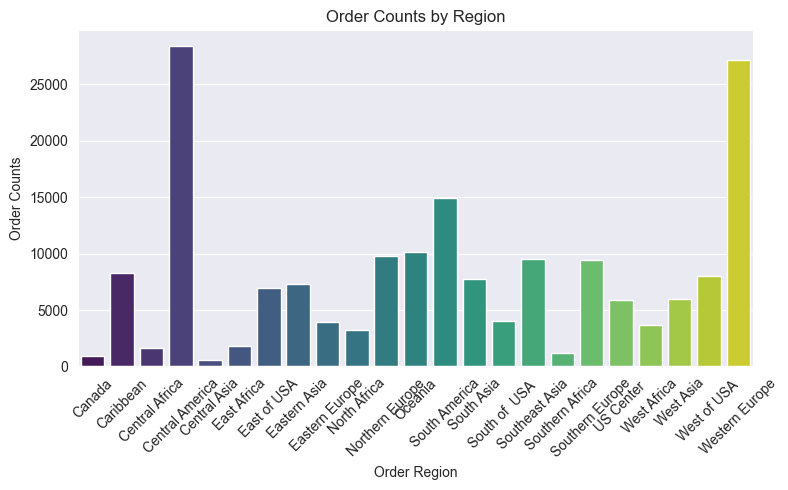

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=order_region_grouped, x='Order Region', y='Order Counts', palette='viridis')
plt.title('Order Counts by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

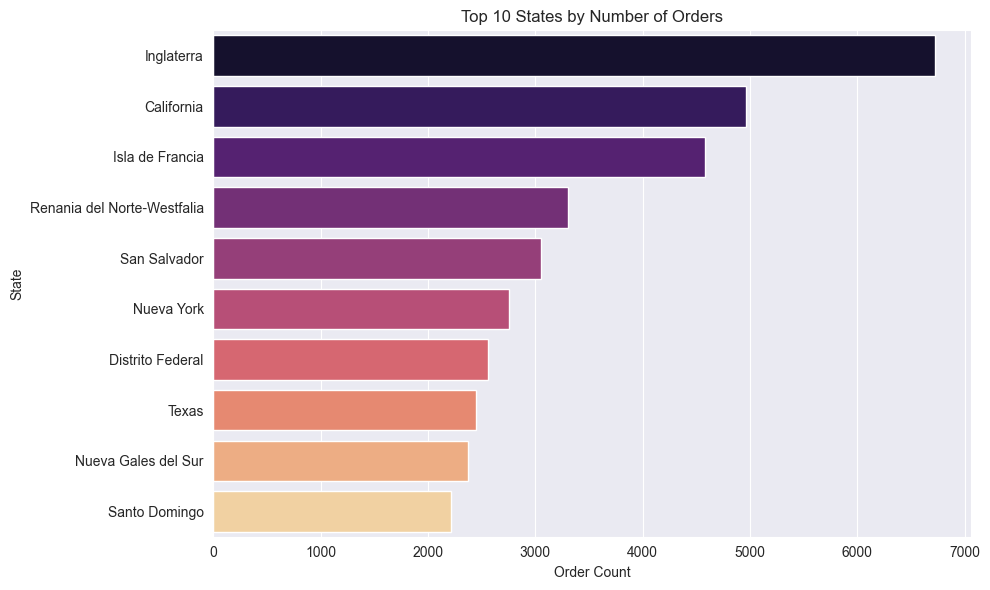

In [194]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, palette='magma')
plt.title('Top 10 States by Number of Orders')
plt.xlabel('Order Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [51]:
region_info = {
    'Canada': ('North America', 56.1304, -106.3468),
    'Caribbean': ('North America', 18.2206, -66.5901),
    'Central Africa': ('Africa', 6.6111, 20.9394),
    'Central America': ('North America', 15.7835, -90.2308),
    'Central Asia': ('Asia', 48.0196, 66.9237),
    'East Africa': ('Africa', -1.2921, 36.8219),
    'East of USA': ('North America', 38.9072, -77.0369),
    'Eastern Asia': ('Asia', 35.8617, 104.1954),
    'Eastern Europe': ('Europe', 50.4501, 30.5234),
    'North Africa': ('Africa', 26.8206, 30.8025),
    'Northern Europe': ('Europe', 60.4720, 8.4689),
    'Oceania': ('Oceania', -25.2744, 133.7751),
    'South America': ('South America', -14.2350, -51.9253),
    'South Asia': ('Asia', 20.5937, 78.9629),
    'South of USA': ('North America', 29.7604, -95.3698),
    'Southeast Asia': ('Asia', 15.8700, 100.9925),
    'Southern Africa': ('Africa', -30.5595, 22.9375),
    'Southern Europe': ('Europe', 41.8719, 12.5674),
    'US Center': ('North America', 39.0997, -94.5786),
    'West Africa': ('Africa', 7.9465, -1.0232),
    'West Asia': ('Asia', 34.5553, 69.2075),
    'West of USA': ('North America', 37.7749, -122.4194),
    'Western Europe': ('Europe', 51.1657, 10.4515)
}

In [52]:
import pandas as pd

data = {
    'Order Region': [
        'Canada', 'Caribbean', 'Central Africa', 'Central America', 'Central Asia', 'East Africa',
        'East of USA', 'Eastern Asia', 'Eastern Europe', 'North Africa', 'Northern Europe', 'Oceania',
        'South America', 'South Asia', 'South of USA', 'Southeast Asia', 'Southern Africa', 'Southern Europe',
        'US Center', 'West Africa', 'West Asia', 'West of USA', 'Western Europe'
    ],
    'Order Counts': [
        959, 8318, 1677, 28341, 553, 1852,
        6915, 7280, 3920, 3232, 9792, 10148,
        14935, 7731, 4045, 9539, 1157, 9431,
        5887, 3696, 6009, 7993, 27109
    ]
}

df = pd.DataFrame(data)

# Map to lat, lon, mapped_region
df[['mapped_region', 'lat', 'lon']] = df['Order Region'].apply(lambda x: pd.Series(region_info.get(x, (None, None, None))))

print(df.head())

      Order Region  Order Counts  mapped_region      lat       lon
0           Canada           959  North America  56.1304 -106.3468
1        Caribbean          8318  North America  18.2206  -66.5901
2   Central Africa          1677         Africa   6.6111   20.9394
3  Central America         28341  North America  15.7835  -90.2308
4     Central Asia           553           Asia  48.0196   66.9237


In [53]:
import plotly.express as px

fig = px.scatter_geo(df,
                     lat='lat',
                     lon='lon',
                     size='Order Counts',
                     color='mapped_region',
                     hover_name='Order Region',
                     projection='natural earth',
                     title='Order Counts by Region (Bubble Map)')

fig.show()